In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


Notebook to calculate the numberof unique iterations that exist for meeting a given maximum intake threshold. Code initially generated with Google Gemini 3.1 pro followed by manual verification.

In [ ]:
%cd /content/drive/MyDrive/mSHIFT_SHeS/code_ocean/

/content/drive/MyDrive/mSHIFT_SHeS/code_ocean


In [ ]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
from pathlib import Path
import sys
import itertools
import math

# Set the plot formatting
plt.rcParams["font.family"] = 'serif'
plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams["axes.formatter.use_mathtext"] = True

# path to where data is stored
data_path = Path("data")

In [ ]:
diet_data = pd.read_parquet(data_path / "diet_data.parquet")
df_baseline = pd.read_parquet(data_path / "df_baseline.parquet")

In [ ]:
RRPM_food_groups = ['Beefg',
 'Lambg',
 'Porkg',
 'Burgersg',
 'OtherRedMeatg',
 'ProcessedRedMeatg',
 'Sausagesg',
 'Offalg']

# Combinatoric functions




In [ ]:


def calculate_combinations(M, boxes):
    """
    Calculates the number of ways to distribute M marbles into N boxes
    with specific capacities, using the Principle of Inclusion-Exclusion.

    Args:
        M (int): The total number of identical marbles.
        boxes (dict): A dictionary where keys are box identifiers (e.g., 1, 2, 3)
                      and values are their integer capacities (e.g., X1, X2, X3).

    Returns:
        int: The total number of valid combinations.
    """

    N = len(boxes)

    # Handles the edge case if the size of the marble is bigger than the box! Happens for a large increment size
    if N == 0:
        return 1 if M == 0 else 0

    # Get just the capacities, as the keys (1, 2, ...) don't matter for the formula
    capacities = list(boxes.values())

    total_combinations = 0

    # This is the 'k' for our binomial coefficient C(n, k), which is N-1
    # It remains constant for every term in the sum.
    k_comb = N - 1

    # 1. Iterate through all possible subset sizes, from 0 to N
    # This k represents |S|
    for k_size_of_S in range(N + 1):

        # 2. Determine the sign for this subset size
        sign = (-1)**k_size_of_S

        # 3. Get all subsets S of this specific size k
        for subset_capacities in itertools.combinations(capacities, k_size_of_S):

            # 4. Calculate the sum of violations for this subset
            # This is sum(Xi + 1) for all i in S
            sum_of_violations = sum(x + 1 for x in subset_capacities)

            # 5. Calculate the 'n' for our binomial coefficient C(n, k)
            n_comb = M - sum_of_violations + N - 1

            # 6. Calculate the binomial coefficient
            # We must handle the case where n_comb is negative.
            # math.comb(n, k) correctly returns 0 if k > n,
            # but we also need to return 0 if n < 0.
            if n_comb < 0:
                term_value = 0
            else:
                # This calculates C(n_comb, k_comb)
                term_value = math.comb(n_comb, k_comb)

            # 7. Add this term (with its sign) to the total
            total_combinations += sign * term_value

    return total_combinations

def calculate_combinatorial_average(M, boxes, calc_comb_func):
    """
    Calculates the exact combinatorial average for each box without
    generating the combinations.

    Args:
        M (int): The total target reduction.
        boxes (dict): Dictionary of food groups and their max capacities.
        calc_comb_func (callable): Your existing calculate_combinations function.

    Returns:
        dict: The combinatorial average reduction for each food group.
    """
    # 1. Get the denominator (total number of valid combinations)
    total_combinations = calc_comb_func(M, boxes)

    if total_combinations == 0:
        return {food: 0.0 for food in boxes} # No solutions exist

    averages = {}

    # 2. Calculate the weighted average for each food group independently
    for target_food, capacity in boxes.items():

        # Isolate the "other" boxes by removing the target_food
        other_boxes = {food: cap for food, cap in boxes.items() if food != target_food}
        weighted_sum = 0

        # A food group can only be reduced up to its capacity, or the total M
        max_possible_reduction = min(capacity, M)

        # 3. Iterate through every possible reduction amount 'k' for this specific food
        for k in range(max_possible_reduction + 1):

            # How many ways can we distribute the REMAINING reduction to the OTHER foods?
            remaining_target = M - k
            combinations_with_k = calc_comb_func(remaining_target, other_boxes)

            # Add to our total weighted sum: (value k) * (number of times k happens)
            weighted_sum += k * combinations_with_k

        # 4. The average is the weighted sum divided by total combinations
        averages[target_food] = weighted_sum / total_combinations

    return averages

def calculate_scaled_averages(consumption_series, target_reduction_g, increment_g, calc_comb_func, calc_avg_func):
    """
    Scales dietary data by a given increment, calculates the combinatorial
    average reduction, and scales the results back to grams.

    Args:
        consumption_series (pd.Series): An individual's meat consumption (index: foods, values: grams).
        target_reduction_g (float/int): The total amount of meat in grams this person needs to reduce.
        increment_g (int): The increment size in grams (e.g., 10, 5, 1).
        calc_comb_func (callable): Your original calculate_combinations function.
        calc_avg_func (callable): The calculate_combinatorial_average function.

    Returns:
        pd.Series: The average reduction in grams for each food group.
    """

    # 1. Discretize the Target Reduction
    # We use floor division to determine how many 'increments' we need to reduce.
    # (e.g., reducing 85g by 10g increments means we need to reduce 8 increments).
    M_discrete = int(target_reduction_g // increment_g)

    # Early exit if the target is too small for the increment
    if M_discrete <= 0:
        return pd.Series(0.0, index=consumption_series.index)

    # 2. Discretize the Capacities (Boxes)
    boxes_discrete = {}
    for food, amount in consumption_series.items():
        # Floor division finds how many complete increments exist in this food group
        capacity = int(amount // increment_g)

        # Only include foods that have at least 1 full increment to give
        if capacity > 0:
            boxes_discrete[food] = capacity

    # Early exit if the discretization makes the target impossible to hit
    if sum(boxes_discrete.values()) < M_discrete:
        # Returns NaNs to flag that this increment size broke the calculation for this person
        return pd.Series(float('nan'), index=consumption_series.index)

    # 3. Calculate Combinatorial Averages in Discrete Space
    discrete_averages = calc_avg_func(M_discrete, boxes_discrete, calc_comb_func)

    # 4. Scale Back to Continuous Space (Grams)
    # Initialize a result Series with zeros to keep the original index/formatting intact
    results_g = pd.Series(0.0, index=consumption_series.index)

    for food, avg_discrete in discrete_averages.items():
        results_g[food] = avg_discrete * increment_g

    return results_g

In [ ]:
plot_path = Path("results/Plots")

In [ ]:
def plot_increment_convergence(consumption_series, target_reduction_g, increments_to_test, calc_comb_func, calc_avg_func):
    """
    Plots the combinatorial average for each food group across different increment sizes.
    """
    # 1. Store the results for each increment
    results_list = []

    for inc in increments_to_test:
        # Run the wrapper function we built earlier
        averages = calculate_scaled_averages(
            consumption_series,
            target_reduction_g,
            inc,
            calc_comb_func,
            calc_avg_func
        )

        # Store the results with the increment size
        averages['Increment'] = inc
        results_list.append(averages)

    # 2. Convert to a DataFrame for easy plotting
    results_df = pd.DataFrame(results_list).set_index('Increment')

    # Drop any rows where the calculation failed (NaNs due to impossible targets)
    results_df = results_df.dropna()

    # 3. Create the Plot
    plt.figure(figsize=(12, 7))

    # Plot a line for every food group
    for food_group in consumption_series.index:
        if consumption_series[food_group] > 0: # Only plot foods they actually ate
            plt.plot(results_df.index, results_df[food_group], marker='o', label=food_group, linewidth=2)

    # 4. Formatting to make it presentation-ready
    plt.title(f'Combinatorial Average Stability vs. Increment Size\n(Target Reduction: {target_reduction_g}g)', fontsize=14)
    plt.xlabel('Increment Size (grams)', fontsize=12)
    plt.ylabel('Average Reduction (grams)', fontsize=12)

    # Invert X-axis so it reads from coarse (50g) to fine (1g) - reading left to right shows convergence
    plt.gca().invert_xaxis()

    # Add a vertical dashed line to highlight your 10g choice
    plt.axvline(x=10, color='red', linestyle='--', alpha=0.7, label='10g Chosen Increment')

    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(title='Food Groups', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig(plot_path / 'combinatorial_average_convergence.png', dpi=300)
    plt.show()


In [ ]:
!ls

capsule-5774929.zip	  code	environment  REPRODUCING.md
capsule_extraction.ipynb  data	metadata     results


In [ ]:
max_intake = 31
id = 1400923801 # 5 meat food groups
#id = 1400000801 # 1 meat food group, only 1 cobinations regardless of choice of gram increment
#id =  1400003001 # 2 food groups

gram_increment = 1
diet = diet_data[diet_data['Cpseriala']==id].copy()
num_days = diet['RecallNo'].max()
meat_food_groups_consumed = diet[RRPM_food_groups].sum(axis=0)/num_days
num_boxes = len(meat_food_groups_consumed[meat_food_groups_consumed > 0])
x = (meat_food_groups_consumed.sum() - max_intake)
num_marbles = int((x - (x % gram_increment))/gram_increment)
boxes_id = {i+1: math.floor(j / gram_increment) for i,j in enumerate(meat_food_groups_consumed[meat_food_groups_consumed > 0])}
combinations = calculate_combinations(M=num_marbles, boxes=boxes_id)

In [ ]:
meat_food_groups_consumed

,0
Beefg,25.06
Lambg,0.00
Porkg,51.60
Burgersg,0.00
OtherRedMeatg,0.00
ProcessedRedMeatg,20.00
Sausagesg,20.00
Offalg,37.50


In [ ]:
mock_consumer

,0
Beefg,45.0
Lambg,22.0
Porkg,115.0
Burgersg,0.0
OtherRedMeatg,12.0
ProcessedRedMeatg,55.0
Sausagesg,38.0
Offalg,0.0


In [ ]:
mock_consumer.to_dict()

{'Beefg': 25.06,
 'Lambg': 0.0,
 'Porkg': 51.6,
 'Burgersg': 0.0,
 'OtherRedMeatg': 0.0,
 'ProcessedRedMeatg': 20.0,
 'Sausagesg': 20.0,
 'Offalg': 37.5}

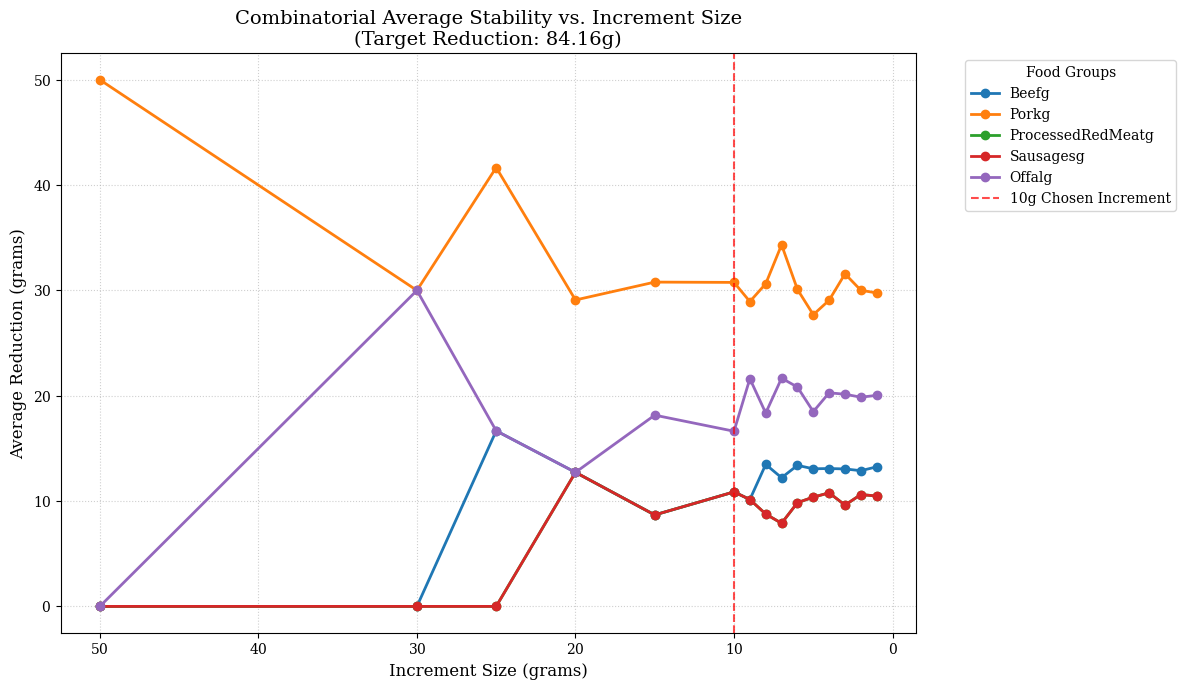

In [ ]:
# mock_consumer = pd.Series({
#     'Beefg': 45.0, 'Lambg': 22.0, 'Porkg': 115.0, 'Burgersg': 0.0,
#     'OtherRedMeatg': 12.0, 'ProcessedRedMeatg': 55.0, 'Sausagesg': 38.0, 'Offalg': 0.0
# })
mock_consumer = pd.Series({'Beefg': 25.06,
 'Lambg': 0.0,
 'Porkg': 51.6,
 'Burgersg': 0.0,
 'OtherRedMeatg': 0.0,
 'ProcessedRedMeatg': 20.0,
 'Sausagesg': 20.0,
 'Offalg': 37.5})
target = 84.16
test_increments = [1, 2,3,4, 5,6,7,8,9, 10, 15, 20, 25, 30, 40, 50]
plot_increment_convergence(mock_consumer, target, test_increments, calculate_combinations, calculate_combinatorial_average)

In [ ]:
mock_consumer.sum()-84.16

np.float64(70.0)

In [ ]:
max_intake


31

In [ ]:
def calculate_population_mse(df_consumers, calc_comb_func, calc_avg_func):
    """
    Calculates the Mean Squared Error between 1g and 10g increment assumptions
    across an entire dataset of consumers.

    Args:
        df_consumers (pd.DataFrame): Rows are consumers, columns are meat food groups.
        target_reductions (pd.Series): The total gram reduction target for each consumer.
        calc_comb_func: The calculate_combinations function.
        calc_avg_func: The calculate_combinatorial_average function.

    Returns:
        pd.DataFrame: A dataframe containing the MSE and Max Error for each consumer.
    """
    error_records = []
    target_reductions = (df_consumers['Total RRPM baseline'] - max_intake).clip(lower=0)
    #df_consumers = [df_consumers['']]

    # Iterate through each consumer
    for idx, consumer_row in df_consumers.iterrows():
        target_g = target_reductions.loc[idx]
        # only want to take the avergage over those that experience a reduction
        if target_g == 0:
            #error_records.append({'Consumer_ID': idx, 'MSE': 0.0, 'Max_Error_g': 0.0})
            continue

        consumer_row = df_consumers.loc[idx, RRPM_food_groups]

        # 1. Calculate the 'Ground Truth' 1g Average
        avg_1g = calculate_scaled_averages(consumer_row, target_g, 1, calc_comb_func, calc_avg_func)

        # 2. Calculate the 10g Approximation
        avg_10g = calculate_scaled_averages(consumer_row, target_g, 10, calc_comb_func, calc_avg_func)

        # Handle cases where calculations were impossible (NaNs)
        if avg_1g.isna().any() or avg_10g.isna().any():
            error_records.append({'Consumer_ID': idx, 'MSE': np.nan, 'Max_Error_g': np.nan})
            continue

        remainder_g = target_g % 10
        if remainder_g > 0:
            # Identify which foods this consumer actually eats (eligible for the random drop)
            eligible_foods = consumer_row[consumer_row > 0].index

            if len(eligible_foods) > 0:
                # Calculate the expected addition (Remainder / Number of eligible foods)
                expected_addition = remainder_g / len(eligible_foods)

                # Add this expected value to the 10g average for those specific foods
                avg_10g[eligible_foods] += expected_addition

        # 3. Calculate Error Metrics
        # Squared differences for each food group
        squared_errors = (avg_1g - avg_10g) ** 2

        # Mean Squared Error for this consumer
        mse = squared_errors.mean()

        # Maximum absolute error for this consumer (often more intuitive than MSE)
        max_error = abs(avg_1g - avg_10g).max()

        error_records.append({
            'Consumer_ID': idx,
            'MSE': mse,
            'Max_Error_g': max_error
        })

    return pd.DataFrame(error_records).set_index('Consumer_ID')

In [ ]:
df_consumers = df_baseline[df_baseline['Total RRPM baseline'] > 0]

In [ ]:
target_reductions

np.float64(123.16)

In [ ]:

idx = 1400923801
target_g = (df_consumers.loc[idx, 'Total RRPM baseline'] - max_intake)

consumer_row = df_consumers.loc[idx, RRPM_food_groups]

# 1. Calculate the 'Ground Truth' 1g Average
avg_1g = calculate_scaled_averages(consumer_row, target_g, 1, calc_comb_func=calculate_combinations, calc_avg_func=calculate_combinatorial_average)

# 2. Calculate the 10g Approximation
avg_10g = calculate_scaled_averages(consumer_row, target_g, 10, calc_comb_func=calculate_combinations, calc_avg_func=calculate_combinatorial_average)

remainder_g = target_g % 10
if remainder_g > 0:
    # Identify which foods this consumer actually eats (eligible for the random drop)
    eligible_foods = consumer_row[consumer_row > 0].index

    if len(eligible_foods) > 0:
        # Calculate the expected addition (Remainder / Number of eligible foods)
        expected_addition = remainder_g / len(eligible_foods)

        # Add this expected value to the 10g average for those specific foods
        avg_10g[eligible_foods] += expected_addition

# 3. Calculate Error Metrics
# Squared differences for each food group
squared_errors = (avg_1g - avg_10g) ** 2

# Mean Squared Error for this consumer
mse = squared_errors.mean()

# Maximum absolute error for this consumer (often more intuitive than MSE)
max_error = abs(avg_1g - avg_10g).max()

In [ ]:
avg_10g

,0
Beefg,16.632
Lambg,0.000
Porkg,46.632
Burgersg,0.000
OtherRedMeatg,0.000
ProcessedRedMeatg,16.632
Sausagesg,16.632
Offalg,26.632


In [ ]:
avg_1g

,0
Beefg,18.898610
Lambg,0.000000
Porkg,44.858053
Burgersg,0.000000
OtherRedMeatg,0.000000
ProcessedRedMeatg,14.192642
Sausagesg,14.192642
Offalg,30.858053


In [ ]:
abs(avg_1g - avg_10g).max()

4.226053302433375

In [ ]:
df_consumers = df_baseline[df_baseline['Total RRPM baseline'] > 0]
error_data = calculate_population_mse(df_consumers=df_consumers,
                                       calc_comb_func=calculate_combinations,
                                      calc_avg_func=calculate_combinatorial_average)

In [ ]:
error_data

,MSE,Max_Error_g
Consumer_ID,,
1400001201,0.118828,0.975000
1400003001,3.062500,3.500000
1400004901,0.070600,0.680000
1400019001,0.001800,0.120000
1400019301,4.045156,4.425000
...,...,...
1405647202,0.006602,0.162500
1405655201,1.561410,3.032675
1405655202,1.581406,2.775000


In [ ]:
error_data['Max_Error_g'].mean()

np.float64(1.4637059447471932)

In [ ]:
error_data['Max_Error_g'].mean()

np.float64(1.4637059447471932)

In [ ]:
error_data['Max_Error_g'].max()

9.223749999999995

In [ ]:
error_data[error_data]

In [ ]:
(error_data['MSE']**0.5).mean()

np.float64(0.4619774161998564)

In [ ]:
df_consumers['Total RRPM baseline']

,Total RRPM baseline
1400000801,27.000
1400001201,65.975
1400003001,97.000
1400004901,201.360
1400006001,19.950
...,...
1405648701,7.225
1405655201,130.000
1405655202,69.550
1405664901,67.020
